In [274]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
df =pd.read_csv("dataset/titanic.csv")

### A simple sample of database

In [96]:
df.head(5)

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### معلومات عامة عن قاعدة البيانات

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     889 non-null    object 
 9   class        891 non-null    object 
 10  who          891 non-null    object 
 11  adult_male   891 non-null    bool   
 12  deck         203 non-null    object 
 13  embark_town  889 non-null    object 
 14  alive        891 non-null    object 
 15  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), object(7)
memory usage: 99.3+ KB


# معلومات اكثر تفصيلاً

### تفاصل الاعمدة

In [251]:
print("Number of columns: ",len(df.columns))
name= []
number = []
vtype = []
for i in df.columns:
    name.append(i)
    number.append(df[i].nunique())
    vtype.append(df[i].dtype)
data = {'Column name': name, 'Number of values': number, 'Type of values': vtype}
d = pd.DataFrame(data)
d

Number of columns:  16


,Column name,Number of values,Type of values
0,Unnamed: 0,891,int64
1,survived,2,int64
2,pclass,3,int64
3,sex,2,object
4,age,88,float64
5,sibsp,7,int64
6,parch,7,int64
7,fare,248,float64
8,embarked,3,object
9,class,3,object


# تفاصيل عن القيم المخزنة

### القيم الفارغة 

In [270]:
name=[]
booling = []
number = []
suming =0
for i in df.columns:
    name.append(i)
    booling.append(df[i].isna().any())
    number.append(df[i].isna().sum())
    suming+= df[i].isna().sum()
data = {'Column name': name, 'Boolean value': booling, 'Number of null value': number}
d = pd.DataFrame(data)
d

,Column name,Boolean value,Number of null value
0,Unnamed: 0,False,0
1,survived,False,0
2,pclass,False,0
3,sex,False,0
4,age,True,177
5,sibsp,False,0
6,parch,False,0
7,fare,False,0
8,embarked,True,2
9,class,False,0


### صورة حرارية للقيم الفارغة

<Axes: >

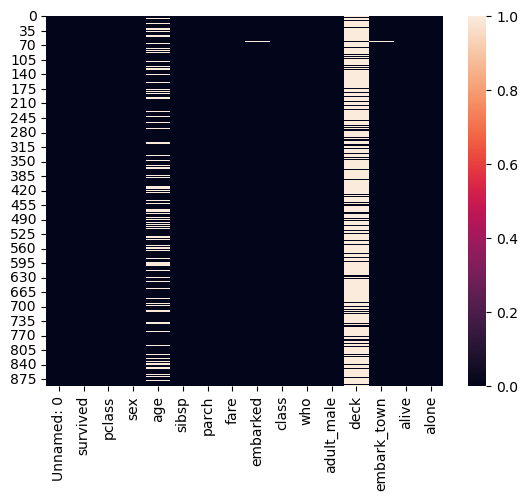

In [275]:
sns.heatmap(df.isna())

<Axes: >

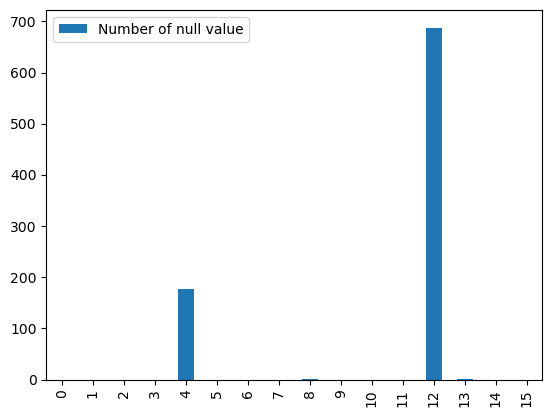

In [278]:
d[['Number of null value','Column name']].plot.bar()

In [284]:
plt.rcParams['figure.figsize']=(15,5)

<BarContainer object of 16 artists>

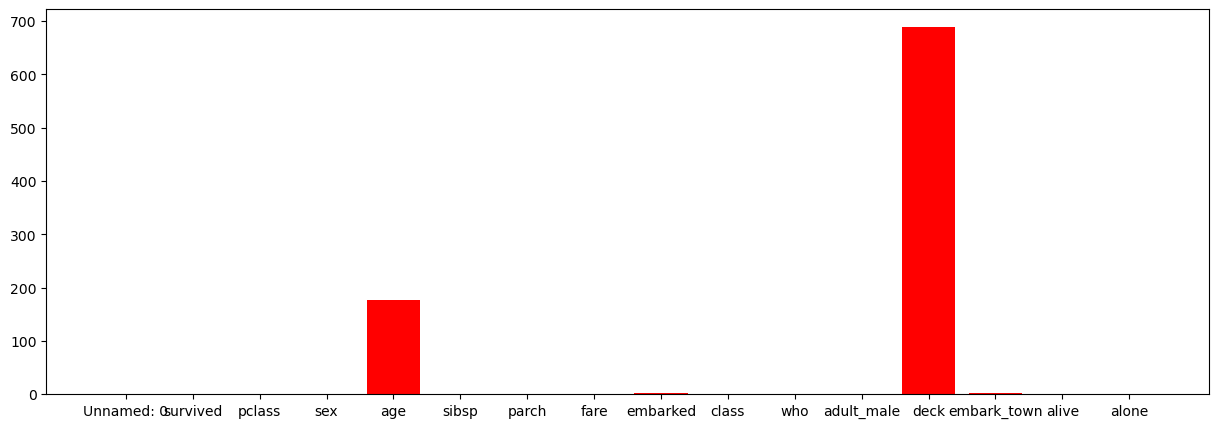

In [285]:
plt.bar(d['Column name'],d['Number of null value'],color='red',alpha=1)

In [279]:
d['Column name']

0      Unnamed: 0
1        survived
2          pclass
3             sex
4             age
5           sibsp
6           parch
7            fare
8        embarked
9           class
10            who
11     adult_male
12           deck
13    embark_town
14          alive
15          alone
Name: Column name, dtype: object

In [271]:
print("Total number of empty values: ",suming)

Total number of empty values:  869


In [273]:
print("Number of duplicate rows: ",df.duplicated().sum())

Number of duplicate rows:  0


### القيم الشاذة

In [308]:
df['fare'].describe().round(3)

count    891.000
mean      32.204
std       49.693
min        0.000
25%        7.910
50%       14.454
75%       31.000
max      512.329
Name: fare, dtype: float64

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

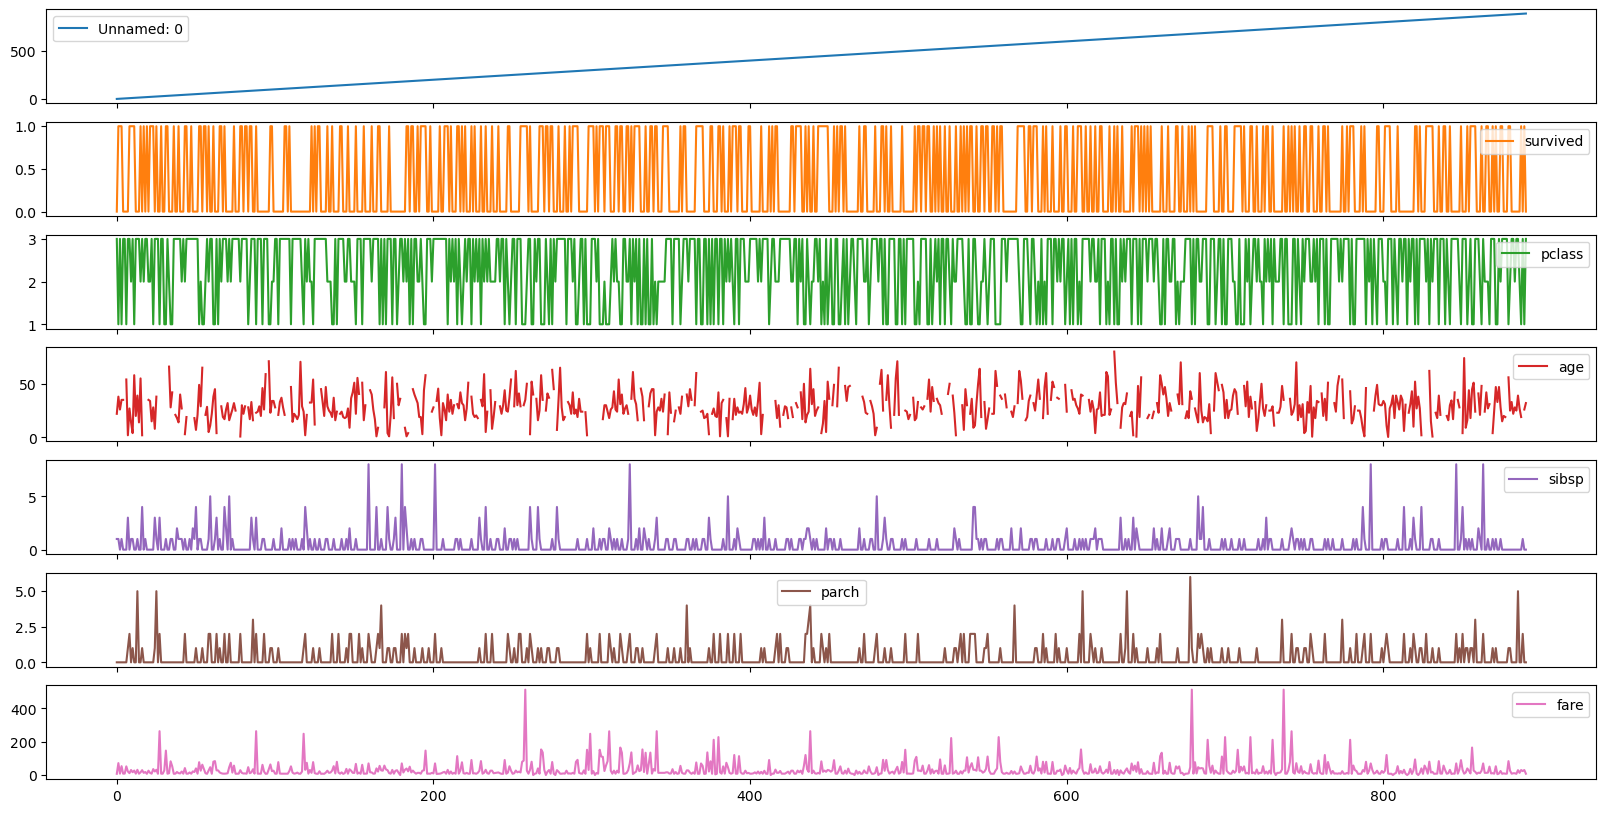

In [286]:
df.plot(subplots=True ,figsize=(20,10))

<Axes: >

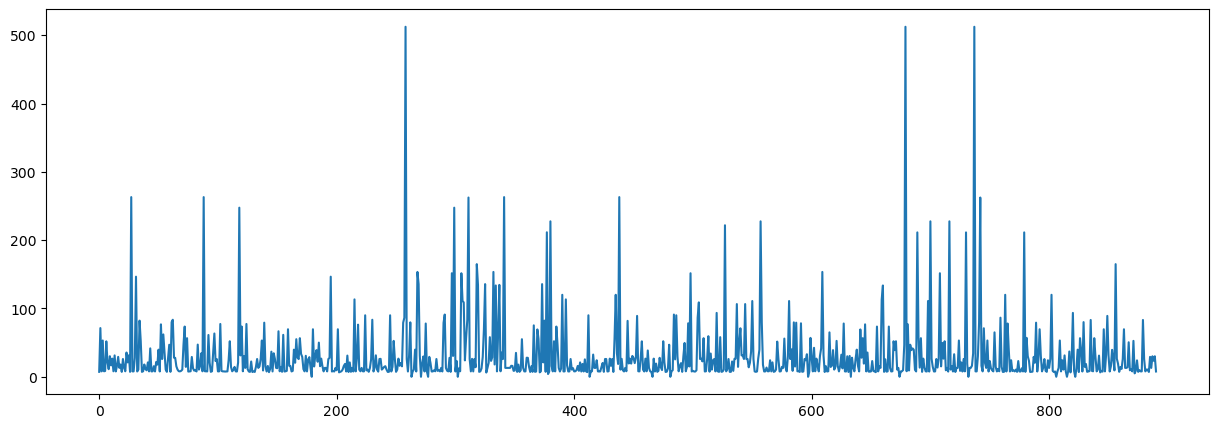

In [287]:
df['fare'].plot()

<Axes: >

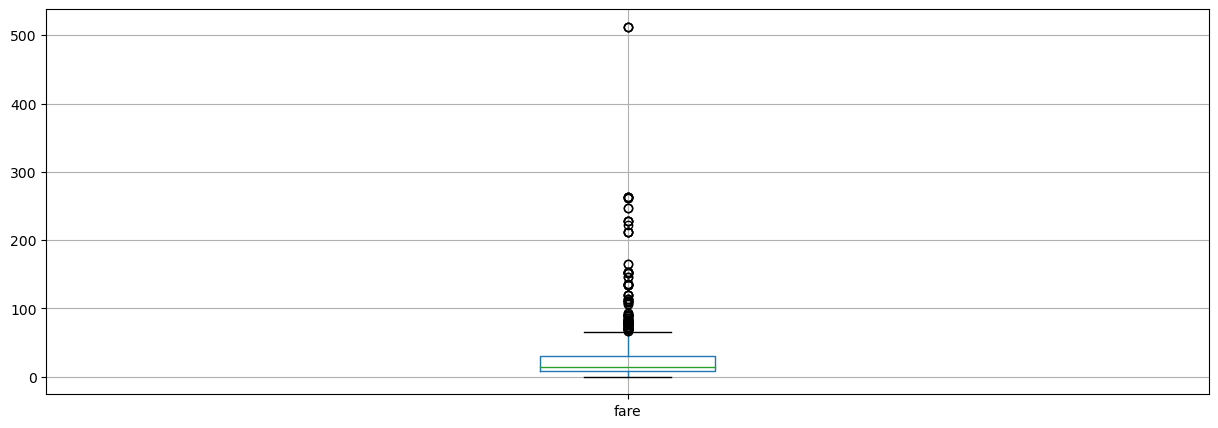

In [288]:
df.boxplot('fare')

### عدد القيم الصفرية الموجودة في الاعمدة

In [389]:
name =[]
value_count=[]
for i in df.columns:
    if 0 in df[i].value_counts().index:
        name.append(i)
        value_count.append(df[i].value_counts()[0])
data = {'column_name':name,'value_count':value_count}
d = pd.DataFrame(data)
d

,column_name,value_count
0,Unnamed: 0,1
1,survived,549
2,sibsp,608
3,parch,678
4,fare,15
